In [53]:
from os import read

import numpy as np
import pandas as pd
import sklearn
from narwhals.selectors import categorical
from select import select
from xgboost import XGBClassifier


In [54]:
import os
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(os.getcwd())
print("Dataset downloaded to:", path)
print(os.listdir(path))



C:\Users\Rushabh\PycharmProjects\churn prediction
Dataset downloaded to: C:\Users\Rushabh\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [55]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print((df.head()))
print(df.shape)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [56]:
print(df.isnull().sum())
print("*" * 25)
print(df.info())
print("*" * 25)
print(df.describe())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
*************************
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043

In [57]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].value_counts().head())

str
TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64


In [58]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].dtypes)
print(df["TotalCharges"].isnull().sum())

float64
11


In [59]:
for column in df.columns:
    print(column, df[column].dtype)

customerID str
gender str
SeniorCitizen int64
Partner str
Dependents str
tenure int64
PhoneService str
MultipleLines str
InternetService str
OnlineSecurity str
OnlineBackup str
DeviceProtection str
TechSupport str
StreamingTV str
StreamingMovies str
Contract str
PaperlessBilling str
PaymentMethod str
MonthlyCharges float64
TotalCharges float64
Churn str


In [60]:
#  DROPPING COLS

In [61]:
df = df.drop(columns=['customerID'])


In [62]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())

(7043, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
T

In [63]:
# Convert text labels to 0 and 1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

#ML MODEL

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [65]:
numeric_feature = X.select_dtypes(include = ["int64", "float64"]).columns
categorical_feature = X.select_dtypes(include = ["object", "category","string"]).columns

In [66]:
print("Numercial:", numeric_feature.tolist())
print("Categorical:", categorical_feature.tolist())

Numercial: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer #Used to fill misssing values

In [68]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [69]:
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

In [70]:
preprocess = ColumnTransformer(
    [
        ("num", numeric_pipeline, numeric_feature),

        ("cat", categorical_pipeline, categorical_feature)
    ]
)

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# This pipeline scales your data first, then runs Logistic Regression with more iterations
model_PipeLine = Pipeline(
    [
        ('preprocessora: ', preprocess),
        ('classifier: ', LogisticRegression())
    ]
)

# Fit it with your training data
model_PipeLine.fit(X_train, y_train)
y_pred = model_PipeLine.predict(X_test)

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664


In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)
print("Precision:", precision * 100)
print("Recall:", recall * 100)
print("F1 Score:", f1 * 100)

Accuracy: 80.55358410220013
Precision: 65.72327044025157
Recall: 55.88235294117647
F1 Score: 60.40462427745664


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy: ", accuracy_score(y_test, rf_pred) * 100)
print("Precision: ", precision_score(y_test, rf_pred) * 100)
print("Recall score: ", recall_score(y_test, rf_pred) * 100)
print("F1_Score: ", f1_score(y_test, rf_pred) * 100)
print(confusion_matrix(y_test, rf_pred))

Accuracy:  77.78566359119942
Precision:  60.33898305084746
Recall score:  47.593582887700535
F1_Score:  53.21375186846039
[[918 117]
 [196 178]]


In [76]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, rf_pred))
print(y_train.value_counts())
print(y_test.value_counts())

[[918 117]
 [196 178]]
Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


#BOTH MODEL SHOWING APPROX SAME

In [77]:
from sklearn.metrics import classification_report,confusion_matrix

print("FOR LOGISITC LEANRING")
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
print(report_df)
print(confusion_matrix(y_test, y_pred))


print("RANDOM FOREST")
report  = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
print(report_df)
print(confusion_matrix(y_test, rf_pred))

FOR LOGISITC LEANRING
              precision    recall  f1-score      support
0              0.848763  0.894686  0.871119  1035.000000
1              0.657233  0.558824  0.604046   374.000000
accuracy       0.805536  0.805536  0.805536     0.805536
macro avg      0.752998  0.726755  0.737583  1409.000000
weighted avg   0.797924  0.805536  0.800228  1409.000000
[[926 109]
 [165 209]]
RANDOM FOREST
              precision    recall  f1-score      support
0              0.824057  0.886957  0.854351  1035.000000
1              0.603390  0.475936  0.532138   374.000000
accuracy       0.777857  0.777857  0.777857     0.777857
macro avg      0.713724  0.681446  0.693244  1409.000000
weighted avg   0.765484  0.777857  0.768824  1409.000000
[[918 117]
 [196 178]]


In [78]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_pipeline= Pipeline([
    ('preprocessor', preprocess),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

gb_pipeline.fit(X_train,y_train)
gb_pred = gb_pipeline.predict(X_test)

In [79]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
print("Accuracy: ",accuracy_score(y_test, gb_pred) * 100)
print("Precision: ",precision_score(y_test, gb_pred) * 100)
print("Recall score: ", recall_score(y_test, gb_pred) * 100)
print("F1_Score: ", f1_score(y_test, gb_pred) * 100)
print(confusion_matrix(y_test, gb_pred))

Accuracy:  80.62455642299503
Precision:  67.35395189003437
Recall score:  52.406417112299465
F1_Score:  58.94736842105262
[[940  95]
 [178 196]]


In [80]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


xgb_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])


xgb_pipeline.fit(X_train, y_train_encoded)


xgb_pred = xgb_pipeline.predict(X_test)

In [81]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
print("Accuracy: ",accuracy_score(y_test_encoded , xgb_pred) * 100)
print("Presicion: ",precision_score(y_test_encoded , xgb_pred) * 100)
print("F1_Score: ", f1_score(y_test_encoded , xgb_pred) * 100)
print("Recall: ", recall_score(y_test_encoded , xgb_pred) * 100)
print(confusion_matrix(y_test_encoded , xgb_pred))


Accuracy:  78.42441447835344
Presicion:  60.54216867469879
F1_Score:  56.94050991501416
Recall:  53.7433155080214
[[904 131]
 [173 201]]


In [82]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


tree_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])


tree_pipeline.fit(X_train, y_train_encoded)
tree_pred = tree_pipeline.predict(X_test)

In [83]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
print("Accuracy: ",accuracy_score(y_test_encoded , tree_pred) * 100)
print("Precision: ",precision_score(y_test_encoded, tree_pred) * 100)
print("Recall score: ", recall_score(y_test_encoded , tree_pred) * 100)
print("F1_Score: ", f1_score(y_test_encoded, tree_pred) * 100)
print(confusion_matrix(y_test_encoded , tree_pred))

Accuracy:  72.88857345635202
Precision:  48.96373056994819
Recall score:  50.534759358288774
F1_Score:  49.73684210526316
[[838 197]
 [185 189]]


In [84]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": 80.41,
    "Precision": 65.31,
    "Recall": 55.88,
    "F1": 60.23
})

results.append({
    "Model": "Gradient Boosting",
    "Accuracy": 80.62,
    "Precision": 67.35,
    "Recall": 52.40,
    "F1": 58.94
})

results.append({
    "Model": "XGBoost",
    "Accuracy": 78.42,
    "Precision": 60.54,
    "Recall": 53.74,
    "F1": 56.94
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": 72.88,
    "Precision": 48.96,
    "Recall": 50.53,
    "F1": 49.73
})

In [85]:
result_df = pd.DataFrame(results)
print(result_df)

                 Model  Accuracy  Precision  Recall     F1
0  Logistic Regression     80.41      65.31   55.88  60.23
1    Gradient Boosting     80.62      67.35   52.40  58.94
2              XGBoost     78.42      60.54   53.74  56.94
3        Decision Tree     72.88      48.96   50.53  49.73


In [86]:
best_model  = result_df.loc[
    result_df["F1"].idxmax()
]
print("Best Model: ", best_model)
print("F1 Score: ", best_model["F1"])

Best Model:  Model        Logistic Regression
Accuracy                   80.41
Precision                  65.31
Recall                     55.88
F1                         60.23
Name: 0, dtype: object
F1 Score:  60.23


#BALANCED

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


balanced_log_model = LogisticRegression(max_iter=5000, class_weight='balanced')


balanced_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', balanced_log_model)
])


balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)

In [88]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
print("--- Balanced Logistic Regression ---")
print("Accuracy: ", accuracy_score(y_test, balanced_pred) * 100)
print("Precision: ", precision_score(y_test, balanced_pred) * 100)
print("Recall: ", recall_score(y_test, balanced_pred) * 100)
print("F1_Score: ", f1_score(y_test, balanced_pred) * 100)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, balanced_pred))

--- Balanced Logistic Regression ---
Accuracy:  73.81121362668559
Precision:  50.4302925989673
Recall:  78.34224598930481
F1_Score:  61.361256544502616

Confusion Matrix:
[[747 288]
 [ 81 293]]


#BALANCED LOGISITC REGRESSION MODEL INCREASED F1SCORE AND RECALL

In [89]:
y_prob = balanced_pipeline.predict_proba(X_test)[:, 1]

print(y_prob)

[0.11547188 0.85307859 0.14683068 ... 0.33480987 0.01361514 0.01787015]


In [90]:
from sklearn.metrics import roc_auc_score


auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc_score * 100)

ROC AUC Score: 84.12978893797307


In [91]:
import numpy as np
from sklearn.metrics import f1_score
thresholds = np.arange(0.1,0.91,0.01)
best_threshold = 0.0
best_f1 = 0
for threshold in thresholds:
    prediction = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test_encoded , prediction)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
print("Best Threshold: ", best_threshold * 100)
print("Best F1: ", best_f1 * 100)


Best Threshold:  53.99999999999998
Best F1:  62.17391304347826


In [92]:
# Apply your winning threshold to generate the final predictions
optimal_pred = (y_prob >= best_threshold).astype(int)

print(f"--- Final Performance at {best_threshold:.2f} Threshold ---")
print("Accuracy: ", accuracy_score(y_test_encoded, optimal_pred) * 100)
print("Precision: ", precision_score(y_test_encoded, optimal_pred) * 100)
print("Recall: ", recall_score(y_test_encoded, optimal_pred) * 100)
print("F1 Score: ", f1_score(y_test_encoded, optimal_pred) * 100)

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test_encoded, optimal_pred))

--- Final Performance at 0.54 Threshold ---
Accuracy:  75.30163236337827
Precision:  52.38095238095239
Recall:  76.47058823529412
F1 Score:  62.17391304347826

Final Confusion Matrix:
[[775 260]
 [ 88 286]]


In [93]:
import pandas as pd


preprocessor = balanced_pipeline.named_steps['preprocessor']
classifier = balanced_pipeline.named_steps['classifier']


feature_names = preprocessor.get_feature_names_out()


coefficients = classifier.coef_[0]


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("--- Top 5 Reasons Customers Churn (Flight Risks) ---")
print(importance_df.head(5))

print("\n--- Top 5 Reasons Customers Stay (Loyal Customers) ---")
print(importance_df.tail(5))

--- Top 5 Reasons Customers Churn (Flight Risks) ---
                             Feature  Importance
16  cat__InternetService_Fiber optic    0.705336
36      cat__Contract_Month-to-month    0.663399
3                  num__TotalCharges    0.457211
35          cat__StreamingMovies_Yes    0.274978
32              cat__StreamingTV_Yes    0.262038

--- Top 5 Reasons Customers Stay (Loyal Customers) ---
                                      Feature  Importance
25  cat__DeviceProtection_No internet service   -0.274568
15                   cat__InternetService_DSL   -0.621009
2                         num__MonthlyCharges   -0.663581
38                     cat__Contract_Two year   -0.781257
1                                 num__tenure   -1.123589


C:\Users\Rushabh\AppData\Local\Temp\ipykernel_10748\1993376961.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_data, palette=colors)


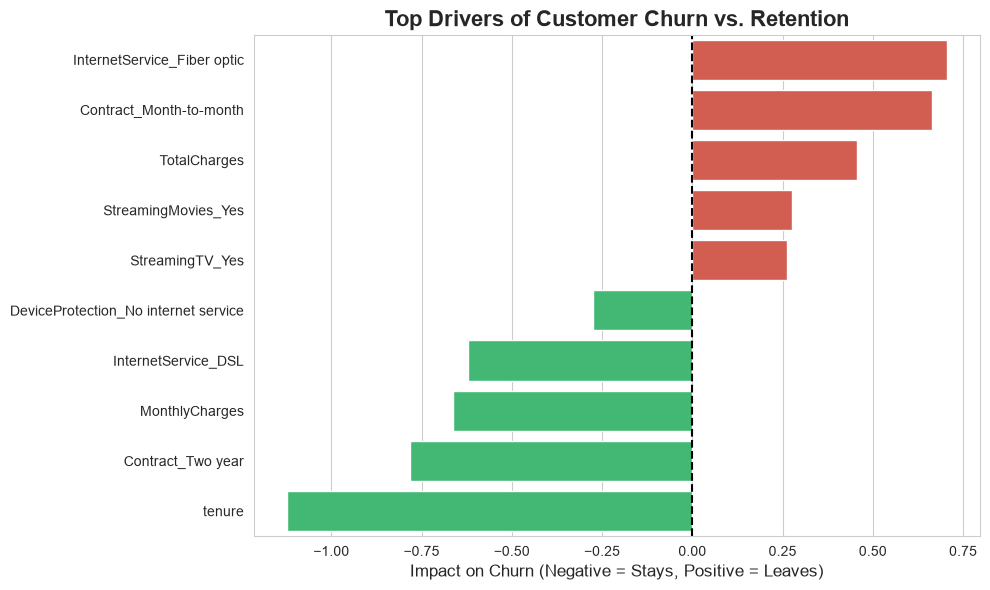

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

top_churn = importance_df.head(5)
top_stay = importance_df.tail(5)

plot_data  = pd.concat([top_churn, top_stay])

plot_data['Feature'] = plot_data['Feature'].str.replace('cat__', '').str.replace('num__', '')

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in plot_data['Importance']]
sns.barplot(x='Importance', y='Feature', data=plot_data, palette=colors)

plt.axvline(x=0, color='black', linestyle='--')
plt.title('Top Drivers of Customer Churn vs. Retention', fontsize=16, fontweight='bold')
plt.xlabel('Impact on Churn (Negative = Stays, Positive = Leaves)', fontsize=12)
plt.ylabel('')
plt.tight_layout()

plt.show()

#GRIDSEARCH

In [95]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1. Build pipeline: preprocessing + model together
log_pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# 2. Prefix each param with the step name ('classifier__')
log_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# 3. Grid search the whole pipeline, not the bare model
grid_log = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Training Logistic Regression Grid Search...")
grid_log.fit(X_train, y_train)
print("Best Logistic Regression Parameters:", grid_log.best_params_)
print("Best Logistic Regression CV AUC Score:", round(grid_log.best_score_ * 100, 2))

# 4. Best full pipeline (preprocessing + tuned model)
best_log_pipeline = grid_log.best_estimator_
log_pred = best_log_pipeline.predict(X_test)

Training Logistic Regression Grid Search...
Best Logistic Regression Parameters: {'classifier__C': 100, 'classifier__solver': 'liblinear'}
Best Logistic Regression CV AUC Score: 84.56


In [96]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
print("Accuracy: ", accuracy_score(y_test, y_pred) * 100)
print("Precision: ", precision_score(y_test, y_pred) * 100)
print("Recall: ", recall_score(y_test, y_pred) * 100)
print("F1Score: ", f1_score(y_test, y_pred) * 100)
print(confusion_matrix(y_test, y_pred))

Accuracy:  80.55358410220013
Precision:  65.72327044025157
Recall:  55.88235294117647
F1Score:  60.40462427745664
[[926 109]
 [165 209]]


# New probabilities from the tuned pipeline

In [97]:

y_prob = best_log_pipeline.predict_proba(X_test)[:, 1]


thresholds = np.arange(0.1, 0.91, 0.01)
best_threshold = 0.0
best_f1 = 0
for threshold in thresholds:
    prediction = (y_prob >= threshold).astype(int)
    f1 = f1_score(y_test, prediction)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold * 100)
print("Best F1:", best_f1 * 100)

Best Threshold: 56.99999999999997
Best F1: 62.07674943566591


In [98]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
xgb_pipeline = Pipeline(
    [
        ('preprocessor', preprocess),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, n_jobs=-1)),
    ]
)
xgb_param_grid ={
    'classifier __C': [0.01, 0.1, 1, 10, 100],
    'classifier __solver': ['liblinear', 'lbfgs']
}
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


print("Training XGBoost Grid Search...")
grid_xgb.fit(X_train, y_train)
print("Best XGBoost Parameters:", grid_xgb.best_params_)
print("Best XGBoost CV AUC Score:", round(grid_xgb.best_score_ * 100, 2))

best_xgb_pipeline = grid_xgb.best_estimator_
xgb_pred = best_xgb_pipeline.predict(X_test)

Training XGBoost Grid Search...
Best XGBoost Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best XGBoost CV AUC Score: 84.83


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

xgb_pred = best_xgb_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, xgb_pred) * 100)
print("Precision:", precision_score(y_test, xgb_pred) * 100)
print("Recall:", recall_score(y_test, xgb_pred) * 100)
print("F1 Score:", f1_score(y_test, xgb_pred) * 100)
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 80.0567778566359
Precision: 67.54716981132076
Recall: 47.860962566844925
F1 Score: 56.02503912363067
[[949  86]
 [195 179]]


In [100]:
xgb_prob = best_xgb_pipeline.predict_proba(X_test)[:, 1]

best_threshold_xgb = 0.0
best_f1_xgb = 0
for threshold in thresholds:
    prediction = (xgb_prob >= threshold).astype(int)
    f1 = f1_score(y_test, prediction)
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_threshold_xgb = threshold

print("Best XGBoost Threshold:", best_threshold_xgb * 100)
print("Best XGBoost F1:", best_f1_xgb * 100)

Best XGBoost Threshold: 33.999999999999986
Best XGBoost F1: 64.08450704225352


In [101]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluate_at_best_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    # Trim precisions/recalls to match thresholds length (drop the last point)
    precisions, recalls = precisions[:-1], recalls[:-1]

    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, y_pred_optimal),
        "Precision": precision_score(y_true, y_pred_optimal),
        "Recall": recall_score(y_true, y_pred_optimal),
        "F1 Score": f1_scores[best_idx],
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "Best Threshold": best_threshold,
    }

log_prob = best_log_pipeline.predict_proba(X_test)[:, 1]
xgb_prob = best_xgb_pipeline.predict_proba(X_test)[:, 1]

results = {
    "Tuned LogReg": evaluate_at_best_f1(y_test, log_prob),
    "Tuned XGBoost": evaluate_at_best_f1(y_test, xgb_prob),
}

comparison_table = pd.DataFrame(results).T.round(4)
comparison_table

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Threshold
Tuned LogReg,0.7608,0.5359,0.7380,0.6209,0.8402,0.5684
Tuned XGBoost,0.7828,0.5711,0.7299,0.6408,0.8456,0.3400


In [102]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\Rushabh\PycharmProjects\churn prediction
['.git', '.idea', '.venv', 'churn_model_pipeline.pkl', 'churn_model_threshold.pkl', 'code.ipynb', 'main.py', 'README.md', '__pycache__']


In [103]:
import os
print(os.listdir())

['.git', '.idea', '.venv', 'churn_model_pipeline.pkl', 'churn_model_threshold.pkl', 'code.ipynb', 'main.py', 'README.md', '__pycache__']


In [104]:
import joblib, os

final_pipeline = best_xgb_pipeline
final_threshold = results["Tuned XGBoost"]["Best Threshold"]

joblib.dump(final_pipeline, "churn_model_pipeline.pkl")
joblib.dump(final_threshold, "churn_model_threshold.pkl")

print("Files in cwd:", os.listdir())
print("Saved threshold:", final_threshold)

Files in cwd: ['.git', '.idea', '.venv', 'churn_model_pipeline.pkl', 'churn_model_threshold.pkl', 'code.ipynb', 'main.py', 'README.md', '__pycache__']
Saved threshold: 0.3400375


In [106]:
import joblib

pipeline = joblib.load("churn_model_pipeline.pkl")
threshold = joblib.load("churn_model_threshold.pkl")

print(type(pipeline))
print(pipeline.named_steps['classifier'])
print("Threshold:", threshold)

<class 'sklearn.pipeline.Pipeline'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)
Threshold: 0.3400375


#sanity-check

In [107]:
loaded_pipeline = joblib.load("churn_model_pipeline.pkl")
loaded_threshold = joblib.load("churn_model_threshold.pkl")

sample_prob = loaded_pipeline.predict_proba(X_test.iloc[:5])[:, 1]
sample_pred = (sample_prob >= loaded_threshold).astype(int)
print(sample_prob, sample_pred)

[0.0651574  0.641857   0.07742105 0.35926306 0.04411435] [0 1 0 1 0]


In [108]:
loaded_pipeline = joblib.load("churn_model_pipeline.pkl")
loaded_threshold = joblib.load("churn_model_threshold.pkl")

sample_prob = loaded_pipeline.predict_proba(X_test.iloc[:5])[:, 1]
sample_pred = (sample_prob >= loaded_threshold).astype(int)
print(sample_prob, sample_pred)

[0.0651574  0.641857   0.07742105 0.35926306 0.04411435] [0 1 0 1 0]
